### This notebook loads the summary of Heart Rate from subjects of Social dataset and looks into systematic differences across tasks

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.anova import AnovaRM

In [2]:
# load HR summary tsv
tsv_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/physio/HR_summary.tsv'
hr_df = pd.read_csv(tsv_path, sep='\t')
hr_df.head()

,subj_id,run_num,task_name,task_code,task_cond,avg_instruction_HR,avg_task_HR
0,sub-05,1,action_prediction,action_prediction,action_prediction_greeting_hard,57.104500,56.659217
1,sub-05,1,frith_happe,frith_happe,frith_happe_tom,57.615986,57.468941
2,sub-05,1,theory_of_mind,tom,theory_of_mind_belief,59.004135,58.739100
3,sub-05,1,strange_stories,strange_stories,strange_stories_social,59.347420,58.251872
4,sub-05,1,liking,liking,liking_like,58.661684,59.130879


In [3]:
# Make sure 'task_cond' is categorical
hr_df['task_cond'] = hr_df['task_cond'].astype('category')

# Reorder categories so 'rest' is first (the reference)
categories = ['rest'] + [t for t in hr_df['task_cond'].cat.categories if t != 'rest']
hr_df['task_cond'] = hr_df['task_cond'].cat.reorder_categories(categories, ordered=True)

In [4]:
# Average across all runs and tasks
subject_means = hr_df.groupby(['subj_id'])[['avg_instruction_HR', 'avg_task_HR']].mean()
print(subject_means)

         avg_instruction_HR  avg_task_HR
subj_id                                 
sub-05            58.002291    57.214634
sub-07            64.375520    63.460780
sub-08            88.347199    86.877729
sub-09            65.481922    63.455794
sub-11            56.642791    56.083582
sub-12            76.773021    75.421942
sub-13            66.709278    65.926690
sub-16            70.355284    69.123470
sub-17            69.444008    69.156437
sub-18            78.186913    77.632758
sub-19            54.370551    54.363048
sub-20            63.421444    62.682151
sub-21            55.475441    54.591091
sub-22            55.319471    53.918020
sub-25            70.791289    68.586750
sub-27            56.600963    55.999074


In [5]:
# Mean difference between instruction and task HR
diffs = subject_means['avg_instruction_HR'] - subject_means['avg_task_HR']
mean_diff = diffs.mean()
sem_diff = diffs.std(ddof=1) / np.sqrt(len(diffs))
print(f"Mean difference (Instruction - Task): {mean_diff:.2f} bpm ± {sem_diff:.2f} (SEM)")

# Paired t-test between instruction and task HR
t_stat, p_value = stats.ttest_rel(subject_means['avg_instruction_HR'], subject_means['avg_task_HR'])
print(f"Paired t-test: t = {t_stat:.3f}, df = {len(subject_means) - 1}, p = {p_value:.3g}")

Mean difference (Instruction - Task): 0.99 bpm ± 0.15 (SEM)
Paired t-test: t = 6.656, df = 15, p = 7.66e-06


In [6]:
# Average across all subjects & runs
task_means = hr_df.groupby('task_cond')[["avg_instruction_HR", "avg_task_HR"]].mean()
task_means['HR_diff'] = task_means['avg_instruction_HR'] - task_means['avg_task_HR']
print(task_means)

                                 avg_instruction_HR  avg_task_HR   HR_diff
task_cond                                                                 
rest                                      65.150072    63.642846  1.507226
action_prediction_greeting_hard           65.297235    64.586073  0.711161
action_prediction_soccer_hard             66.108981    65.229472  0.879509
demand_grid                               65.395849    65.911900 -0.516051
faux_pas_control                          65.471500    65.178954  0.292547
faux_pas_social                           65.513528    65.122506  0.391022
frith_happe_random                        65.898400    64.341467  1.556933
frith_happe_tom                           65.322472    63.360797  1.961676
liking_control                            65.861918    64.719553  1.142364
liking_like                               65.573935    64.897375  0.676559
picture_sequence_control                  65.640026    64.427952  1.212074
picture_sequence_fbelief 

In [7]:
# Find the two task_conds with lowest and highest avg_task_HR
lowest_tasks = task_means['avg_task_HR'].nsmallest(2)
highest_tasks = task_means['avg_task_HR'].nlargest(2)

print("Lowest 2 avg_task_HR:")
for task, val in lowest_tasks.items():
    print(f"{task}: {val:.2f}")

print("\nHighest 2 avg_task_HR:")
for task, val in highest_tasks.items():
    print(f"{task}: {val:.2f}")

Lowest 2 avg_task_HR:
frith_happe_tom: 63.36
rest: 63.64

Highest 2 avg_task_HR:
demand_grid: 65.91
action_prediction_soccer_hard: 65.23


In [8]:
# Average across runs
run_means = hr_df.groupby(['subj_id', 'task_cond'], as_index=False)[['avg_instruction_HR', 'avg_task_HR']].mean()

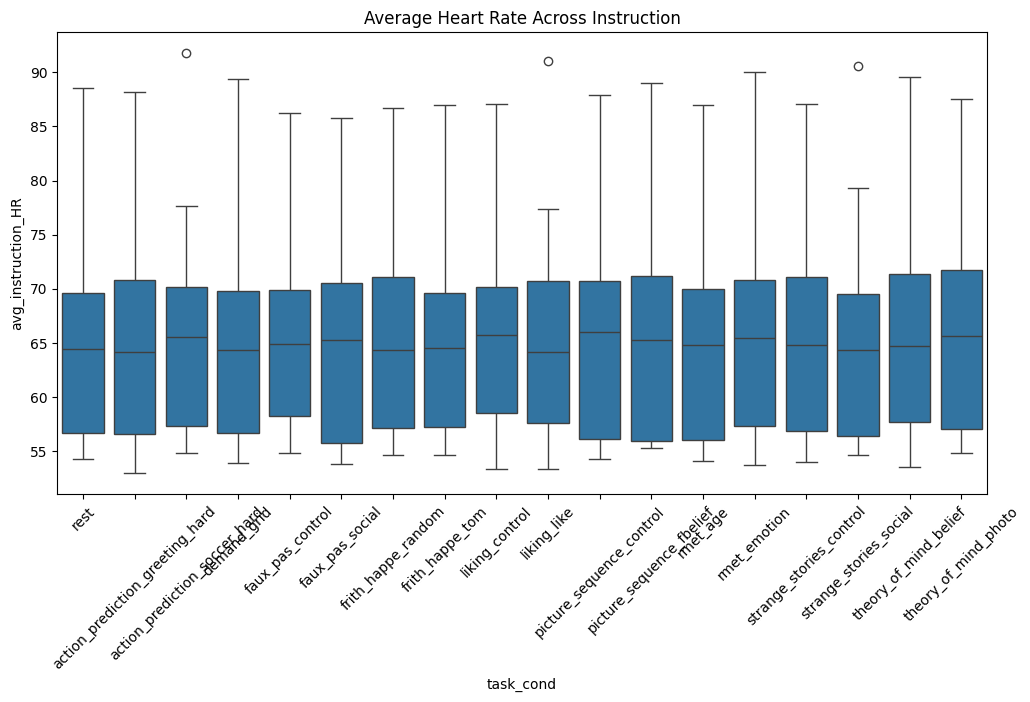

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='task_cond', y="avg_instruction_HR", data=run_means)
plt.title("Average Heart Rate Across Instruction")
plt.xticks(rotation=45)
plt.show()

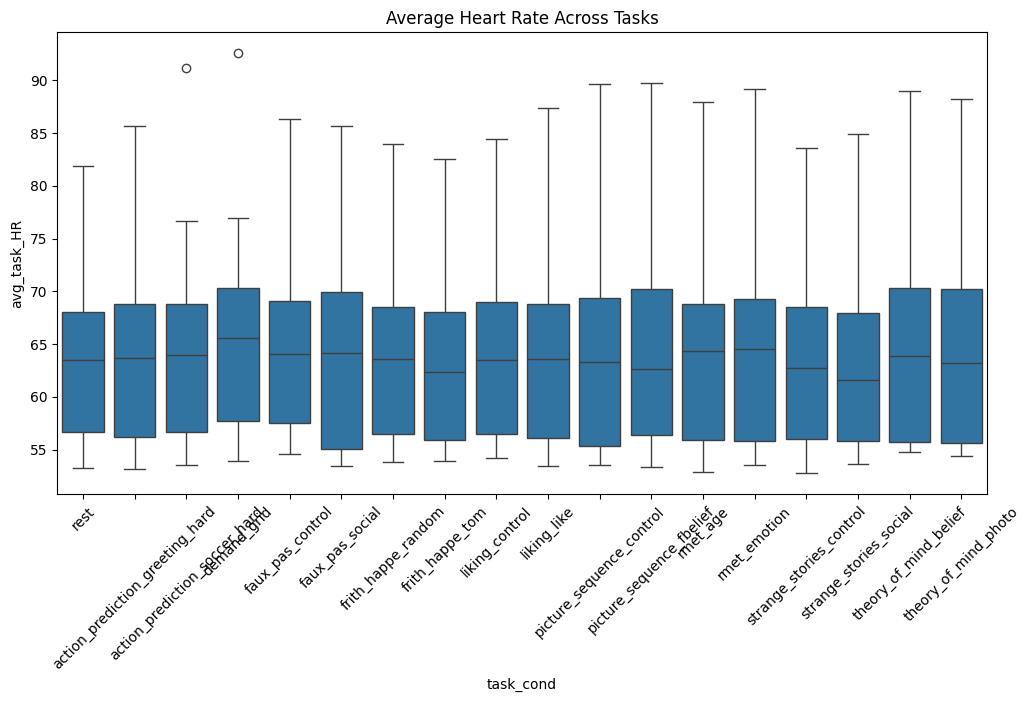

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='task_cond', y="avg_task_HR", data=run_means)
plt.title("Average Heart Rate Across Tasks")
plt.xticks(rotation=45)
plt.show()

In [11]:
# Average HR across runs per subject per task
subject_task_avg = hr_df.groupby(['subj_id','task_cond'])['avg_task_HR'].mean().reset_index()

aov = AnovaRM(
    data=subject_task_avg,
    depvar="avg_task_HR",   # dependent variable
    subject="subj_id",      # repeated measure identifier
    within=['task_cond']    # within-subject factors
).fit()

print(aov)

                  Anova
          F Value  Num DF  Den DF  Pr > F
-----------------------------------------
task_cond  3.1222 17.0000 255.0000 0.0000

